In [ ]:
#!pip install re

In [ ]:
#!pip install nltk

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Importing requests to extract content from a url
import nltk
from nltk.corpus import stopwords
import pandas as pd
import re

# Vader Lexicon

In [3]:
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/geethikapanikker/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [4]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer

In [5]:
sia = SentimentIntensityAnalyzer()

In [7]:
a = 'This was a disgrace on the screen. An utter waste of time.'

In [8]:
sia.polarity_scores(a)

{'neg': 0.4, 'neu': 0.6, 'pos': 0.0, 'compound': -0.7184}

In [9]:
b = 'Great movie. Thoroughly enjoyed it'

In [10]:
sia.polarity_scores(b)

{'neg': 0.0, 'neu': 0.281, 'pos': 0.719, 'compound': 0.8268}

In [11]:
def get_vader_sentiment(review): 
    ''' 
    Utility function to classify sentiment of passed tweet 
    using textblob's sentiment method 
    '''
    sia = SentimentIntensityAnalyzer()
    # create TextBlob object of passed tweet text 
    analysis = sia.polarity_scores(review)
    # set sentiment 
    if analysis["compound"] > 0: 
        return 'pos'
    else: 
        return 'neg'

In [12]:
get_vader_sentiment(b)

'pos'

In [15]:
rev = "This is a bad movie "

In [16]:
get_vader_sentiment(rev)

'neg'

## Amazon Reviews

In [17]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer
sid = SentimentIntensityAnalyzer()

In [18]:
import numpy as np
import pandas as pd

In [20]:
df = pd.read_csv('../../datasets/amazonreviews.tsv', sep='\t')
df.head()

,label,review
0,pos,Stuning even for the non-gamer: This sound tra...
1,pos,The best soundtrack ever to anything.: I'm rea...
2,pos,Amazing!: This soundtrack is my favorite music...
3,pos,Excellent Soundtrack: I truly like this soundt...
4,pos,"Remember, Pull Your Jaw Off The Floor After He..."


In [21]:
df['label'].value_counts()

label
neg    5097
pos    4903
Name: count, dtype: int64

In [22]:
df.loc[0]['review']

'Stuning even for the non-gamer: This sound track was beautiful! It paints the senery in your mind so well I would recomend it even to people who hate vid. game music! I have played the game Chrono Cross but out of all of the games I have ever played it has the best music! It backs away from crude keyboarding and takes a fresher step with grate guitars and soulful orchestras. It would impress anyone who cares to listen! ^_^'

In [23]:
sid.polarity_scores(df.loc[0]['review'])

{'neg': 0.088, 'neu': 0.669, 'pos': 0.243, 'compound': 0.9454}

In [24]:
get_vader_sentiment(df.loc[0]['review'])

'pos'

In [25]:
df['comp_score'] = df['review'].apply(get_vader_sentiment)
df

,label,review,comp_score
0,pos,Stuning even for the non-gamer: This sound tra...,pos
1,pos,The best soundtrack ever to anything.: I'm rea...,pos
2,pos,Amazing!: This soundtrack is my favorite music...,pos
3,pos,Excellent Soundtrack: I truly like this soundt...,pos
4,pos,"Remember, Pull Your Jaw Off The Floor After He...",pos
...,...,...,...
9995,pos,A revelation of life in small town America in ...,pos
9996,pos,Great biography of a very interesting journali...,pos
9997,neg,Interesting Subject; Poor Presentation: You'd ...,pos
9998,neg,Don't buy: The box looked used and it is obvio...,neg


In [26]:
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

In [27]:
accuracy_score(df['label'],df['comp_score'])

0.713

In [28]:
print(classification_report(df['label'],df['comp_score']))

              precision    recall  f1-score   support

         neg       0.85      0.53      0.65      5097
         pos       0.65      0.90      0.75      4903

    accuracy                           0.71     10000
   macro avg       0.75      0.72      0.70     10000
weighted avg       0.75      0.71      0.70     10000



In [29]:
print(confusion_matrix(df['label'],df['comp_score']))

[[2716 2381]
 [ 489 4414]]


## Rule Based Approach

In [30]:
# Importing requests to extract content from a url
from nltk.corpus import stopwords
import matplotlib.pyplot as plt
from wordcloud import WordCloud

In [34]:
# Reading reviews from a text file 
with open("../../datasets/iphone.txt","r",encoding='utf8') as input:
    iphone_reviews = input.read()
type(iphone_reviews)   
#iphone_reviews

str

In [36]:
ip_rev_string = re.sub("[^A-Za-z]+"," ",iphone_reviews).lower()
#ip_rev_string

In [37]:
# Example
ret = re.sub("[^A-Za-z]+"," ","abc@Xy8z")
ret

'abc Xy z'

In [45]:
# words that contained in iphone 7 reviews
ip_reviews_words = ip_rev_string.split(" ")
#ip_reviews_words

In [46]:
st1 = "I love python very much"

In [47]:
st1.split(' ')

['I', 'love', 'python', 'very', 'much']

In [48]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/geethikapanikker/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [49]:
stop_words = stopwords.words('english')

In [51]:
## Remove stop words from reviews - Only words NOT matching stopwordlist is taken
ip_reviews_words = [w for w in ip_reviews_words if not w in stop_words]
#ip_reviews_words

In [53]:
# Joinining all the reviews into single paragraph 
ip_rev_string = " ".join(ip_reviews_words)
#ip_rev_string

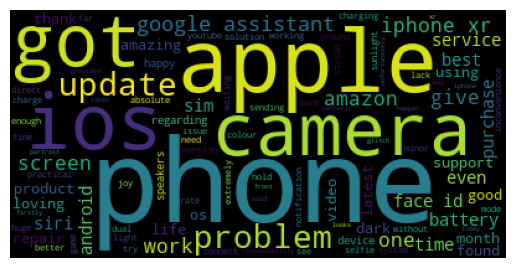

In [54]:
# Simple word cloud
wordcloud_ip = WordCloud(
                      background_color='black',
                      max_words = 100
                     ).generate(ip_rev_string)

plt.imshow(wordcloud_ip)
plt.axis("off")
plt.show()

In [55]:
# positive words # Choose the path for +ve words stored in system
with open("../../datasets/positive-words.txt","r") as pos:
    poswords = pos.read().split("\n")

In [56]:
# negative words  Choose path for -ve words stored in system
with open("../../datasets/negative-words.txt","r") as neg:
    negwords = neg.read().split("\n")

In [57]:
# Choosing the only words which are present in negwords
ip_neg_in_neg = " ".join ([w for w in ip_reviews_words if w in negwords])
ip_neg_in_neg

'unfortunately glitch pathetic bomb issue dark problem disabled dark clash problem miss flaws inconvenience dark lack inconvenience criticism problem problem problem lack problem delay pain lying failed dead issue bothering'

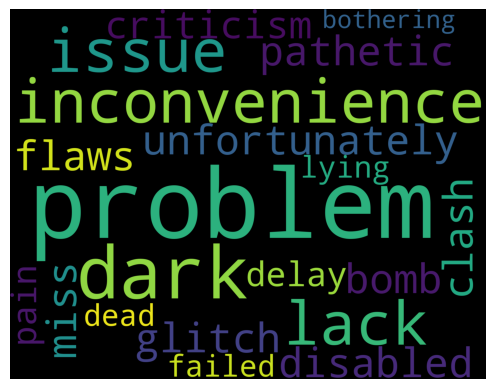

In [58]:
wordcloud_neg_in_neg = WordCloud(
                      background_color='black',
                      width=1800,
                      height=1400
                     ).generate(ip_neg_in_neg)

plt.imshow(wordcloud_neg_in_neg)
plt.axis("off")

plt.show()

In [60]:
# Choosing the only words which are present in positive words
ip_pos_in_pos = " ".join ([w for w in ip_reviews_words if w in poswords])

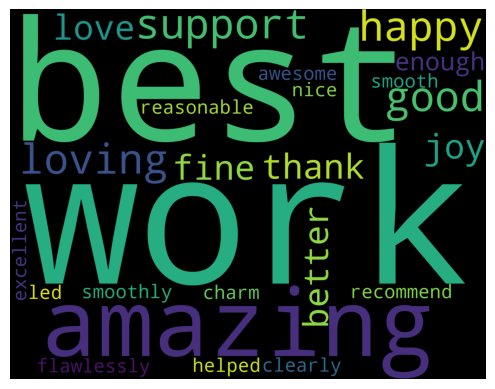

In [61]:
# Positive word cloud
wordcloud_pos_in_pos = WordCloud(
                      background_color='black',
                      width=1800,
                      height=1400
                     ).generate(ip_pos_in_pos)
plt.imshow(wordcloud_pos_in_pos)
plt.axis("off")
plt.show()

In [62]:
len(ip_pos_in_pos)

335

In [63]:
len(ip_neg_in_neg)

222